# Collaborative Filtering

Collaborative filtering is a popular technique for building recommendation systems. Build a user-based collaborative filtering by applying SVD on the user-movie ratings.data

# Load dataset

In [202]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
from sklearn.metrics.pairwise import cosine_similarity
from numpy.linalg import svd
from lightfm.cross_validation import random_train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import confusion_matrix, classification_report
from itertools import product
from scipy.sparse import csr_matrix

#### Description of dataset

**u.data** -- The full u data set, 100000 ratings by 943 users on 1682 items. Each user has rated at least 20 movies. Users and items are numbered consecutively from 1. The data is randomly ordered. This is a tab separated list of **user id** | **item id** | **rating** | **timestamp**. The time stamps are unix seconds since 1/1/1970 UTC
\
\
**u.info** -- The number of users, items, and ratings in the u data set.
\
\
**u.item** -- Information about the items (movies); this is a tab separated list of 
|**movie id** | **movie title** | **release date** | **video release date** |

| IMDb URL | unknown | Action | Adventure | Animation |
| Children's | Comedy | Crime | Documentary | Drama | Fantasy |
| Film-Noir | Horror | Musical | Mystery | Romance | Sci-Fi |
| Thriller | War | Western |

The last 19 fields are the genres, a 1 indicates the movie is of that genre, a 0 indicates it is not; movies can be in several genres at once. The movie ids are the ones used in the u.data data set.
\
\
**u.genre** -- A list of the genres.
\
\
**u.user** -- Demographic information about the users; this is a tab separated list of **user id** | **age** | **gender** | **occupation** | **zip code**. The user ids are the ones used in the u.data data set.
\
\
**u.occupation** -- A list of the occupations.
\
\
**ua.train** **ua.test** -- The data sets ua.train and ua.test split the u data into a training set and a test set with exactly 10 ratings per user in the test set.

<span style="color: blue">Question: </span> Load the csv files in variables.

In [2]:
u_data_columns = ['user_id', 'item_id', 'rating', 'timestamp']
u_item_columns = [
    'item_id', 'movie_title', 'release_date', 'video_release_date', 'IMDb_url',
    'unknown', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy',
    'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
    'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
]
u_genre_columns = ['genre', 'genre_id']
u_user_columns = ['user_id', 'age', 'gender', 'occupation', 'zip_code']
u_occupation_columns = ['occupation']


ratings = pd.read_csv('data/ua.train', delimiter='\t', header=None, names=u_data_columns)
items = pd.read_csv('data/u.item', delimiter='|', header=None, names=u_item_columns, encoding='latin-1')


# Looking into dataset

#### itmes Dataset:

In [3]:
# Display the first few rows of the items dataset
items.head()

,item_id,movie_title,release_date,video_release_date,IMDb_url,unknown,Action,Adventure,Animation,Children,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [4]:
# Get basic information about the dataset
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   item_id             1682 non-null   int64  
 1   movie_title         1682 non-null   object 
 2   release_date        1681 non-null   object 
 3   video_release_date  0 non-null      float64
 4   IMDb_url            1679 non-null   object 
 5   unknown             1682 non-null   int64  
 6   Action              1682 non-null   int64  
 7   Adventure           1682 non-null   int64  
 8   Animation           1682 non-null   int64  
 9   Children            1682 non-null   int64  
 10  Comedy              1682 non-null   int64  
 11  Crime               1682 non-null   int64  
 12  Documentary         1682 non-null   int64  
 13  Drama               1682 non-null   int64  
 14  Fantasy             1682 non-null   int64  
 15  Film-Noir           1682 non-null   int64  
 16  Horror

In [5]:
# Get summary statistics
items.describe()

,item_id,video_release_date,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
count,1682.000000,0.0,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,...,1682.00000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000
mean,841.500000,NaN,0.001189,0.149227,0.080262,0.024970,0.072533,0.300238,0.064804,0.029727,...,0.01308,0.014269,0.054697,0.033294,0.036266,0.146849,0.060048,0.149227,0.042212,0.016052
std,485.695893,NaN,0.034473,0.356418,0.271779,0.156081,0.259445,0.458498,0.246253,0.169882,...,0.11365,0.118632,0.227455,0.179456,0.187008,0.354061,0.237646,0.356418,0.201131,0.125714
min,1.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,421.250000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,841.500000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1261.750000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1682.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### ratings Dataset:

In [6]:
# Display the first few rows of the ratings dataset
ratings.head()

,user_id,item_id,rating,timestamp
0,1,1,5,874965758
1,1,2,3,876893171
2,1,3,4,878542960
3,1,4,3,876893119
4,1,5,3,889751712


In [7]:
# Get basic information about the dataset
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90570 entries, 0 to 90569
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   user_id    90570 non-null  int64
 1   item_id    90570 non-null  int64
 2   rating     90570 non-null  int64
 3   timestamp  90570 non-null  int64
dtypes: int64(4)
memory usage: 2.8 MB


In [8]:
# Get summary statistics
ratings.describe()

,user_id,item_id,rating,timestamp
count,90570.000000,90570.000000,90570.000000,9.057000e+04
mean,461.494038,428.104891,3.523827,8.835073e+08
std,266.004364,333.088029,1.126073,5.341684e+06
min,1.000000,1.000000,1.000000,8.747247e+08
25%,256.000000,174.000000,3.000000,8.794484e+08
50%,442.000000,324.000000,4.000000,8.828143e+08
75%,682.000000,636.000000,4.000000,8.882049e+08
max,943.000000,1682.000000,5.000000,8.932866e+08


# Preprocessing

In [9]:
# Drop video_release_date_column
items = items.drop('video_release_date', axis = 1)

# Convert release_date column into pandas date time format
items['release_date'] = pd.to_datetime(items['release_date'])

# Impute missing values in `release_date` with the median value
items['release_date'] = items['release_date'].fillna(items['release_date'].median())

items.head()

,item_id,movie_title,release_date,IMDb_url,unknown,Action,Adventure,Animation,Children,Comedy,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),1995-01-01,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),1995-01-01,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),1995-01-01,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),1995-01-01,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),1995-01-01,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


Look for duplicates in the data.

In [10]:
# Check for duplicate rows in the movies DataFrame
duplicates_movies = items[items.duplicated()]
print("\nDuplicate Rows in 'movies' DataFrame:")
print(duplicates_movies)

# Check for duplicate rows in the 'ratings' DataFrame
duplicates_ratings = ratings[ratings.duplicated()]
print("\nDuplicate Rows in 'ratings' DataFrame:")
print(duplicates_ratings)


Duplicate Rows in 'movies' DataFrame:
Empty DataFrame
Columns: [item_id, movie_title, release_date, IMDb_url, unknown, Action, Adventure, Animation, Children, Comedy, Crime, Documentary, Drama, Fantasy, Film-Noir, Horror, Musical, Mystery, Romance, Sci-Fi, Thriller, War, Western]
Index: []

[0 rows x 23 columns]

Duplicate Rows in 'ratings' DataFrame:
Empty DataFrame
Columns: [user_id, item_id, rating, timestamp]
Index: []


In [13]:
ratings['item_id'].max(), ratings['item_id'].min(), ratings['user_id'].max(), ratings['user_id'].min()

(1682, 1, 943, 1)

# Preparing the Ratings Matrix (User - Item Matrix)

In [14]:
# Sample DataFrame
t_data = ratings[['user_id', 'item_id', 'rating']]

# Pivot the DataFrame
pivoted_df_na = t_data.pivot(index='user_id', columns='item_id', values='rating')

# Remove the index and column names
pivoted_df_na.index.name = None
pivoted_df_na.columns.name = None
pivoted_df = pivoted_df_na.fillna(0)
pivoted_df.head()

,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
pivoted_df.shape

(943, 1680)

# Train-Validation Interactions Split

In [23]:
scipy_df = csr_matrix(pivoted_df.values)

In [ ]:
# Initialise a validation interactions dataset for hyperparameter tuning
# Using the function under the LightFM library
train_interactions, val_interactions = random_train_test_split(scipy_df, test_percentage=0.2, random_state=42)

In [25]:
train_interactions

<943x1680 sparse matrix of type '<class 'numpy.float64'>'
	with 72456 stored elements in COOrdinate format>

In [27]:
val_interactions

<943x1680 sparse matrix of type '<class 'numpy.float64'>'
	with 18114 stored elements in COOrdinate format>

In [ ]:
class SVDRecommender:
    def __init__(self, n_factors=10, n_similar_users=10):
        self.n_factors = n_factors # Number of latent factors
        self.n_similar_users = n_similar_users # Number of similar users to search from and consider

    def fit(self, interactions):
        # Fits the ratings matrix / interactions matrix into the svd function, essentially creating the SVD Matrices
        # Store the interactions in memory for future use.
        self.interactions = interactions

        # Apply SVD on the ratings matrix (Likewise from Tutorial Code)
        self.u, self.s, self.vh = self._apply_svd(self.interactions, self.n_factors)

    def predict(self, user_ids):
        # Initialise a predictions list to store all the predictions for each user id 
        predictions = []
        
        # Loop through all users
        for uid in user_ids: 
            # Find similar users for the specified user (uid)
            similar_user_dict = self._similar_users(uid, self.u, self.n_factors)
            
            # Sort similar users by similarity score in descending orders
            sim_user = [(user_id, sim) for user_id, sim in similar_user_dict.items() if user_id != uid]
            sim_user = sorted(sim_user, key=lambda x: x[1], reverse=True)[:self.n_similar_users]
            
            #Initialise a vector for storing predicted ratings for each item
            user_predictions = np.zeros(self.interactions.shape[1])

            #  loop through each item to predict the rating for the target user
            for item_id in range(self.interactions.shape[1]):
                if self.interactions[uid, item_id] != 0:
                    # If the user has already rated this item, use the existing rating
                    # This step is here to prevent any errors, ultimately the recommender engine will not
                    # recommend items that the user has already seen before. In the later steps.
                    user_predictions[item_id] = self.interactions[uid, item_id]
                else:
                    # Calculate a weighted average rating for this item from similar neighbors
                    # The weight used will be the similarity score between the user and the queried neighbour
                    weighted_sum = 0
                    similarity_sum = 0
                    
                    for neighbor_id, similarity in sim_user:
                        # Check if the neighbor has rated the item
                        neighbor_rating = self.interactions[neighbor_id, item_id]
                        if neighbor_rating != 0:
                            # Accumulate weighted ratings and similarity sums
                            weighted_sum += neighbor_rating * similarity
                            similarity_sum += similarity
                    
                    # Calculate the predicted rating as a weighted average, if possible
                    if similarity_sum > 0:
                        user_predictions[item_id] = weighted_sum / similarity_sum
                    else:
                        # If no similar neighbors have rated this movie, the predicted rating is 0 
                        user_predictions[item_id] = 0

            # Add the user's predicted ratings to the predictions list
            predictions.append(user_predictions)

        return np.array(predictions)  # Return as a NumPy array for MSE calculation

    # convert ratings matrix into SVD matrices
    # extracted from Tutorial's Code
    def _apply_svd(self, ratings_matrix, n_factors):
        u, s, vh = svd(ratings_matrix, full_matrices=False)

        # Creating diagonal sigma matrix
        s = np.diag(s[:n_factors])
        u = u[:, :n_factors]
        vh = vh[:n_factors, :]
        return u, s, vh

    # finding similar users from the SVD matrices
    # extracted from Tutorial's Code
    def _similar_users(self, user_id, u1, n_factors):
        # Create a dictionary to store similarity scores
        similarity_dict = {}
        
        # Extract the first n_elements from u1
        u2 = u1[:, :n_factors]
        
        # Iterate over each user (row) in u2
        for col in range(u2.shape[0]):
            # Calculate cosine similarity between the user_id's row and the current user's row
            similarity_dict[col] = cosine_similarity(u2[user_id, :].reshape(1, -1), u2[col, :].reshape(1, -1))[0, 0]
        
        # Return the dictionary of similarity scores
        return similarity_dict


We use the Mean Absolute Error as our loss function. This will tell us the mean difference in ratings between our predictions and the actual ground truth ratings.

In [ ]:
from sklearn.metrics import mean_absolute_error

def evaluate_mae(predicted_ratings, true_ratings):
    # Mask to compare only non-zero entries in the true ratings interactions data
    mask = true_ratings != 0

    # Filter predictions and true ratings based on the mask and compute the MAE for those ratings!
    filtered_predictions = predicted_ratings[mask]
    filtered_true_ratings = true_ratings[mask]

    # Calculate MAE
    mae = mean_absolute_error(filtered_true_ratings, filtered_predictions)

    return mae


In [ ]:
from sklearn.metrics import mean_absolute_error
from itertools import product
import numpy as np

# Our choice of param grid to achieve hyperparameter optimisation
param_grid = {
    'n_factors': [5, 10, 15, 20],
    'n_similar_users': [5, 10, 15, 20]
}

# Initialising the history of best parameters from the Grid Search Cross Validation
best_score = float('inf')
best_params = None

# For each combination of the hyperparameter
for n_factors, n_similar_users in product(param_grid['n_factors'], param_grid['n_similar_users']):
    # Initialize the model with the current parameters
    model = SVDRecommender(n_factors=n_factors, n_similar_users=n_similar_users)
    
    # Fit the model on the training interactions
    model.fit(train_interactions.toarray())
    
    # Predict ratings for all users in the validation set
    user_ids = range(val_interactions.shape[0])  # Generate user IDs for validation set
    predictions = model.predict(user_ids)  # Get predictions for all users in validation set
    
    # Calculate the MAE on the validation set
    true_ratings = val_interactions.toarray()  # Convert sparse validation matrix to dense
    mae = evaluate_mae(predictions, true_ratings)
    
    # Print current parameters and MAE
    print(f"Parameters: n_factors={n_factors}, n_similar_users={n_similar_users}, MAE={mae}")
    
    # update the best parameters if the current score is better
    if mae < best_score:
        best_score = mae
        best_params = {'n_factors': n_factors, 'n_similar_users': n_similar_users}

# Output the best parameters and score
print("Best parameters:", best_params)
print("Best MAE:", best_score)


Parameters: n_factors=5, n_similar_users=5, MAE=1.7947814770453663
Parameters: n_factors=5, n_similar_users=10, MAE=1.4038491512037736
Parameters: n_factors=5, n_similar_users=15, MAE=1.237367917696776
Parameters: n_factors=5, n_similar_users=20, MAE=1.1304546779686642
Parameters: n_factors=10, n_similar_users=5, MAE=1.7426843274677442
Parameters: n_factors=10, n_similar_users=10, MAE=1.3493645541136512
Parameters: n_factors=10, n_similar_users=15, MAE=1.1868997950992657
Parameters: n_factors=10, n_similar_users=20, MAE=1.0926612244599985
Parameters: n_factors=15, n_similar_users=5, MAE=1.7556355549092302
Parameters: n_factors=15, n_similar_users=10, MAE=1.3571228664821195
Parameters: n_factors=15, n_similar_users=15, MAE=1.1975755231660572
Parameters: n_factors=15, n_similar_users=20, MAE=1.0982767731055707
Parameters: n_factors=20, n_similar_users=5, MAE=1.79382072297708
Parameters: n_factors=20, n_similar_users=10, MAE=1.3972706270676667
Parameters: n_factors=20, n_similar_users=15,

# Generating Recommendations

In [166]:
# Load the data
test = pd.read_csv('data/ua.test', sep='\t', names=['user_id', 'item_id', 'rating', 'timestamp'])

# Transform ratings into binary variable
test['binary_rating'] = test['rating'].apply(lambda x: 'Like' if x >= 4 else 'Dislike')

# Drop the timestamp column
test = test.drop(columns=['timestamp'])

# Set as dislike for now, we will change the predicted rating to like if the movie has been recommended to the user
test["predicted_rating"] = "Dislike"

# Display the transformed DataFrame
print(test.head())

   user_id  item_id  rating binary_rating predicted_rating
0        1       20       4          Like          Dislike
1        1       33       4          Like          Dislike
2        1       61       4          Like          Dislike
3        1      117       3       Dislike          Dislike
4        1      155       2       Dislike          Dislike


In [ ]:
# Initialise model with best parameters
model = SVDRecommender(**best_params)

# For each user, make a maximum of 6 recommendations sorted in descending order of ratings (Allows sliceing the recommendations)
num_items_to_recommend = 6 

# Fit on the entire training dataset (train + val) without test
model.fit(pivoted_df.to_numpy())

# Create dictionary to store recommended movies
recommended_movies = {}

# Specify target users from test set
test_user_ids = test['user_id'].unique()

for target_user_id in test_user_ids:
    # Get predicted ratings for the target user
    target_user_predictions = model.predict([target_user_id - 1])[0]  # Adjust for zero-based index

    # Get movies the target user has already seen (from training data)
    seen_items = t_data[t_data['user_id'] == target_user_id]['item_id'].unique()

    # Set movies the user has already seen
    # +1 to item_id since the movie_ids in the actual data are one-based indexed
    unseen_items = {item_id: target_user_predictions[item_id] for item_id in range(len(target_user_predictions)) if item_id + 1 not in seen_items}
    unseen_items = list(unseen_items.items())
    random.shuffle(unseen_items)  # Shuffle to ensure random natural ordering and allow random selection of movies in tie-breaker ratings predictions scenarios

    # Sort unseen items by predicted rating in descending order
    # item_recommendations consist of (movie_id, predicted rating) pairs
    # Natural order is now random, movies with tiebreakers ratings will be randomly selected
    item_recommendations = sorted(unseen_items, key=lambda x: x[1], reverse=True)[:num_items_to_recommend]

    # Extract the movie ids
    movie_recommendations = [pair[0] for pair in item_recommendations]

    # Store in dictionary
    recommended_movies[target_user_id] = movie_recommendations
    
print("All recommendations generated!")

All recommendations generated!


In [ ]:
recommended_movies[1] # Recommended movies for uid = 1 for K= 6 recommendations for example

[1102, 1198, 640, 583, 792, 1285]

# Evaluation of our recommendations

In [204]:
# Ensuring a fresh initation of the test data
test = pd.read_csv('data/ua.test', sep='\t', names=['user_id', 'item_id', 'rating', 'timestamp'])

# Transform ratings into binary variable
test['binary_rating'] = test['rating'].apply(lambda x: 1 if x >= 4 else 0) # 1 for Like, 0 for Dislike

# Drop the timestamp column
test = test.drop(columns=['timestamp'])

# Set as dislike for now, we will change the predicted rating to like if the movie has been recommended to the user
test["predicted_rating"] = 0

# Display the transformed DataFrame
print(test.head())

   user_id  item_id  rating  binary_rating  predicted_rating
0        1       20       4              1                 0
1        1       33       4              1                 0
2        1       61       4              1                 0
3        1      117       3              0                 0
4        1      155       2              0                 0


## Finding overlaps between predictions and ground truth

In [ ]:
# Maps K to a Test Dataframe containing a predicted_rating column
k_results = {} 

for K in range(1, 7):
    k_recommendations = {}
    # Slice the K

    for uid, recommendations in recommended_movies.items():
        # Slice up to K recommendations
        k_recommendations[uid] = recommendations[:K]

    # For Debugging
    # print(k_recommendations[1])

    # Create a deep copy of the test dataframe
    temp_test = test.copy(deep = True)

    # set the predicted ratings to Like if it is found in the test set
    for uid in test['user_id'].unique():
        temp_test.loc[(temp_test['item_id'].isin(k_recommendations[uid])) & (temp_test['user_id'] == uid) , 'predicted_rating'] = 1

    k_results[K] = temp_test

## Confusion Matrix and Classification Report

*** Confusion Matrix for Top K = 1 recommendations ***


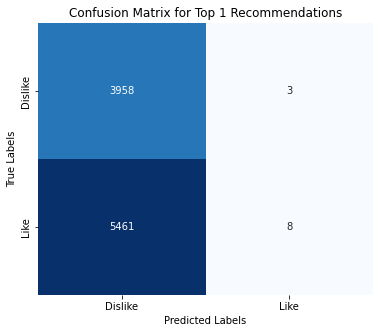

*** Classification Report for Top 1 recommendation ***
              precision    recall  f1-score   support

           0       0.42      1.00      0.59      3961
           1       0.73      0.00      0.00      5469

    accuracy                           0.42      9430
   macro avg       0.57      0.50      0.30      9430
weighted avg       0.60      0.42      0.25      9430



*** Confusion Matrix for Top K = 2 recommendations ***


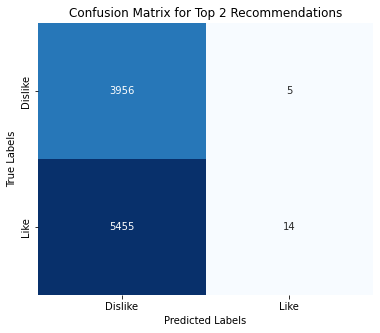

*** Classification Report for Top 2 recommendation ***
              precision    recall  f1-score   support

           0       0.42      1.00      0.59      3961
           1       0.74      0.00      0.01      5469

    accuracy                           0.42      9430
   macro avg       0.58      0.50      0.30      9430
weighted avg       0.60      0.42      0.25      9430



*** Confusion Matrix for Top K = 3 recommendations ***


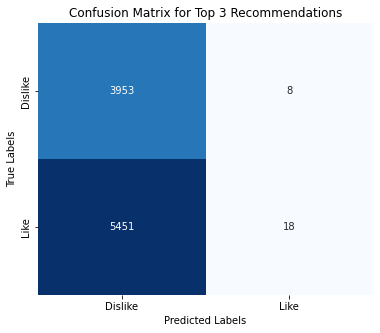

*** Classification Report for Top 3 recommendation ***
              precision    recall  f1-score   support

           0       0.42      1.00      0.59      3961
           1       0.69      0.00      0.01      5469

    accuracy                           0.42      9430
   macro avg       0.56      0.50      0.30      9430
weighted avg       0.58      0.42      0.25      9430



*** Confusion Matrix for Top K = 4 recommendations ***


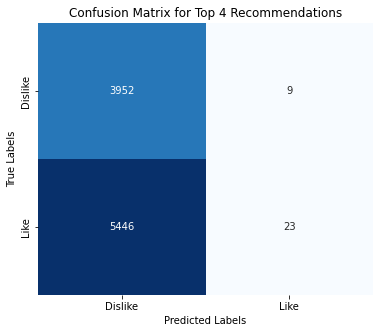

*** Classification Report for Top 4 recommendation ***
              precision    recall  f1-score   support

           0       0.42      1.00      0.59      3961
           1       0.72      0.00      0.01      5469

    accuracy                           0.42      9430
   macro avg       0.57      0.50      0.30      9430
weighted avg       0.59      0.42      0.25      9430



*** Confusion Matrix for Top K = 5 recommendations ***


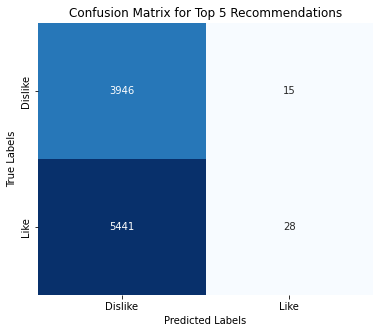

*** Classification Report for Top 5 recommendation ***
              precision    recall  f1-score   support

           0       0.42      1.00      0.59      3961
           1       0.65      0.01      0.01      5469

    accuracy                           0.42      9430
   macro avg       0.54      0.50      0.30      9430
weighted avg       0.55      0.42      0.25      9430



*** Confusion Matrix for Top K = 6 recommendations ***


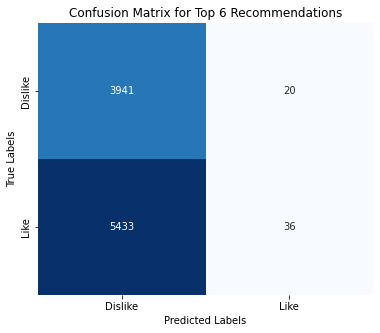

*** Classification Report for Top 6 recommendation ***
              precision    recall  f1-score   support

           0       0.42      0.99      0.59      3961
           1       0.64      0.01      0.01      5469

    accuracy                           0.42      9430
   macro avg       0.53      0.50      0.30      9430
weighted avg       0.55      0.42      0.26      9430





In [231]:
report_data = {'K': [], 'Precision': [], 'Recall': [], '1 - Precision (False Discovery Rate)': []}

for K in k_results.keys():
    y_true = k_results[K]['binary_rating']
    y_pred = k_results[K]['predicted_rating']

    print(f"*** Confusion Matrix for Top K = {K} recommendations ***")
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", cbar=False, xticklabels=['Dislike', 'Like'], yticklabels=['Dislike', 'Like'])
    
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'Confusion Matrix for Top {K} Recommendations')
    plt.show()

    print(f"*** Classification Report for Top {K} recommendation ***")
    # For table
    cr = classification_report(y_true, y_pred)
    print(cr)
    
    # For graphing
    cr = classification_report(y_true, y_pred, output_dict = True)
    precision = cr['1']['precision']
    recall = cr['1']['recall']
    one_minus_precision = 1 - precision  # Calculate 1 - Precision for label 1

    # Append metrics to report data
    report_data['K'].append(K)
    report_data['Precision'].append(precision)
    report_data['Recall'].append(recall)
    report_data['1 - Precision (False Discovery Rate)'].append(one_minus_precision)

    print("\n")


In [232]:
report_df = pd.DataFrame(report_data)
report_df

,K,Precision,Recall,1 - Precision (False Discovery Rate)
0,1,0.727273,0.001463,0.272727
1,2,0.736842,0.002560,0.263158
2,3,0.692308,0.003291,0.307692
3,4,0.718750,0.004206,0.281250
4,5,0.651163,0.005120,0.348837
5,6,0.642857,0.006583,0.357143


## Evaluation Metric 1: Precision

Text(0.5, 0, 'K number of recommendations')

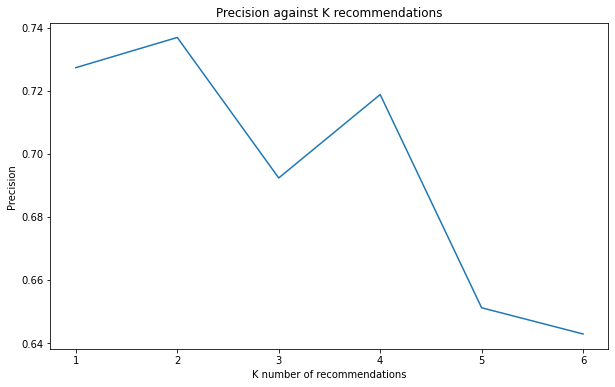

In [233]:
plt.figure(figsize=(10, 6), facecolor='white')
plt.plot(report_df['K'], report_df['Precision'], label='Precision')
plt.title("Precision against K recommendations")
plt.ylabel("Precision")
plt.xlabel("K number of recommendations")

## Evaluation Metric 2: Recall

Text(0.5, 0, 'K number of recommendations')

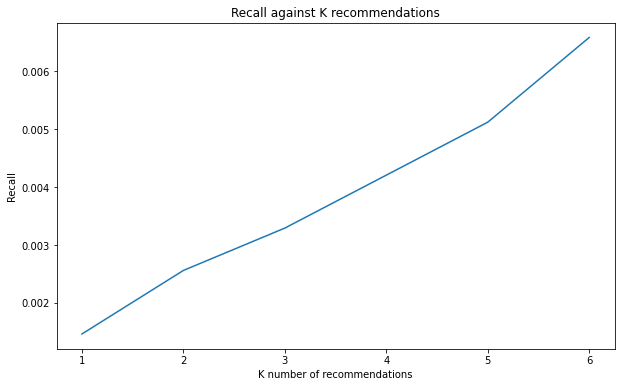

In [234]:
plt.figure(figsize=(10, 6), facecolor='white')
plt.plot(report_df['K'], report_df['Recall'])
plt.title("Recall against K recommendations")
plt.ylabel("Recall")
plt.xlabel("K number of recommendations")

## ## Evaluation Metric 3: 1 - Precision (False Discovery Rate)

Text(0.5, 0, 'K number of recommendations')

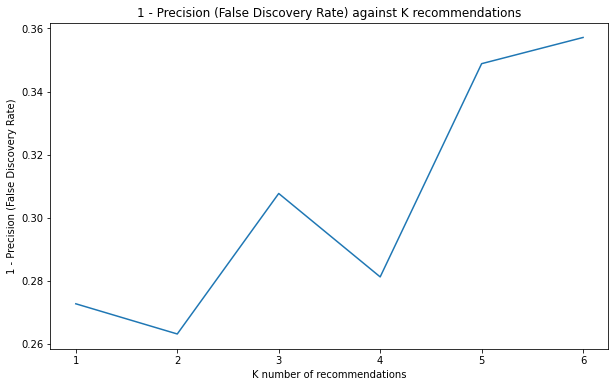

In [235]:
plt.figure(figsize=(10, 6), facecolor='white')
plt.plot(report_df['K'], report_df['1 - Precision (False Discovery Rate)'])
plt.title("1 - Precision (False Discovery Rate) against K recommendations")
plt.ylabel("1 - Precision (False Discovery Rate)")
plt.xlabel("K number of recommendations")

## Combined Plot of First 3 Evaluation Metrics

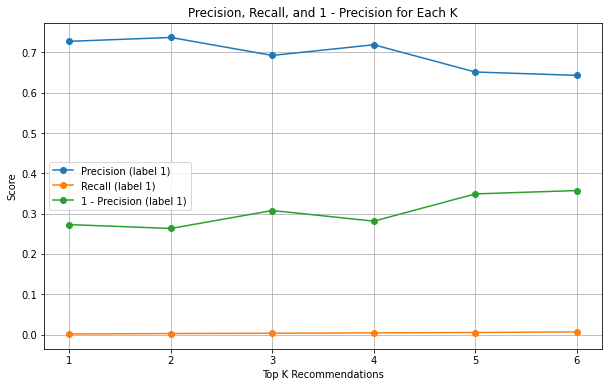

In [236]:
plt.figure(figsize=(10, 6), facecolor='white')
plt.plot(report_df['K'], report_df['Precision'], marker='o', label='Precision (label 1)')
plt.plot(report_df['K'], report_df['Recall'], marker='o', label='Recall (label 1)')
plt.plot(report_df['K'], report_df['1 - Precision (False Discovery Rate)'], marker='o', label='1 - Precision (label 1)')
plt.xlabel('Top K Recommendations')
plt.ylabel('Score')
plt.title('Precision, Recall, and 1 - Precision for Each K')
plt.legend()
plt.grid(True)
plt.show()

## Evaluation Metric 4 and 5: Hit Rate and Coverage

In [247]:
hitrates = []
coverages = []
hits = []

for K, k_result in k_results.items():
    # Count the number of users with at least 1 'Hit'
    # A 'Hit' is represented as a match between the predicted movie and the ground truth liked movie
    users_with_hits = k_result[(k_result['predicted_rating'] == 1) & (k_result['binary_rating'] == 1)]['user_id'].nunique()
    # Hits
    hits.append(users_with_hits)
    total_users = k_result['user_id'].nunique()

    # Calculate hit rate
    hitrate = users_with_hits / total_users
    hitrates.append(hitrate)

    print(f"Number of User Hits for K = {K} is", users_with_hits)
    print(f"Hit Rate for K = {K} is ", hitrate)

    # Coverage calculation
    recommended_items = k_result[k_result['predicted_rating'] == 1]['item_id'].nunique()
    total_items = k_result['item_id'].nunique()
    coverage = recommended_items / total_items
    print(f"Coverage for K = {K} is ", coverage)
    coverages.append(coverage)
    print("\n")

Number of User Hits for K = 1 is 8
Hit Rate for K = 1 is  0.008483563096500531
Coverage for K = 1 is  0.00974313551815766


Number of User Hits for K = 2 is 14
Hit Rate for K = 2 is  0.014846235418875928
Coverage for K = 2 is  0.01682905225863596


Number of User Hits for K = 3 is 18
Hit Rate for K = 3 is  0.019088016967126194
Coverage for K = 3 is  0.021257750221434897


Number of User Hits for K = 4 is 23
Hit Rate for K = 4 is  0.024390243902439025
Coverage for K = 4 is  0.026572187776793623


Number of User Hits for K = 5 is 27
Hit Rate for K = 5 is  0.02863202545068929
Coverage for K = 5 is  0.030115146147032774


Number of User Hits for K = 6 is 35
Hit Rate for K = 6 is  0.03711558854718982
Coverage for K = 6 is  0.03720106288751107




Text(0.5, 0, 'K number of recommendations')

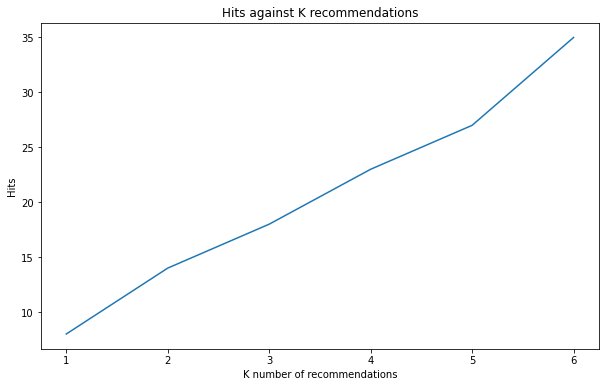

In [250]:
plt.figure(figsize=(10, 6), facecolor='white')
plt.plot(range(1, 7), hits)
plt.title("Hits against K recommendations")
plt.ylabel("Hits")
plt.xlabel("K number of recommendations")

Text(0.5, 0, 'K number of recommendations')

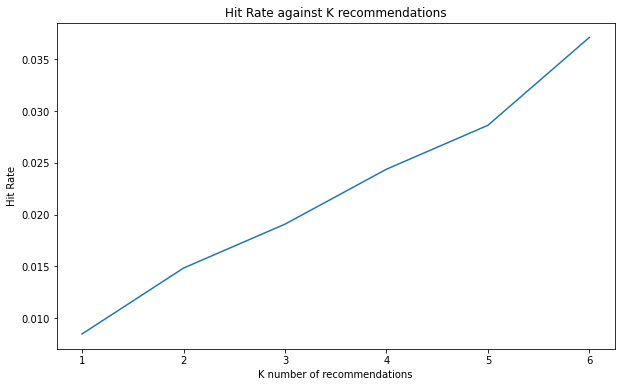

In [248]:
plt.figure(figsize=(10, 6), facecolor='white')
plt.plot(range(1, 7), hitrates)
plt.title("Hit Rate against K recommendations")
plt.ylabel("Hit Rate")
plt.xlabel("K number of recommendations")

Text(0.5, 0, 'K number of recommendations')

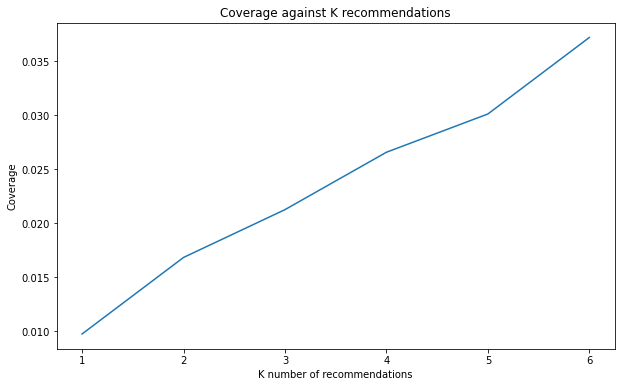

In [249]:
plt.figure(figsize=(10, 6), facecolor='white')
plt.plot(range(1, 7), coverages)
plt.title("Coverage against K recommendations")
plt.ylabel("Coverage")
plt.xlabel("K number of recommendations")